Today: one integrated worked example — Pandas (L8), plotting (L9), Materials Project (L10), filtering (L11), loops (L12) — then Quiz 2.

> Quiz 2 is given in class today. HW5 due this week. No new syntax.

# The bar for today

*Can you take a raw CSV and, on your own, load it, filter it, loop over something, summarize it, and make one honest plot?*

The Quiz 2 checklist:

1. Load + inspect: `pd.read_csv`, `.head()`, `.shape`, `.columns`, `.dtypes`
2. Select: `df['col']`, `df[['a', 'b']]`, `.loc`, boolean masks
3. Combine conditions: `&` / `|` with parentheses
4. `for` loop over rows (`.iterrows()`) or unique values — accumulate a count/sum/list
5. Summary stats: `.mean()`, `.median()`, `.std()` — per-category via loop + mask, not `.groupby()` (Lecture 15)
6. One Matplotlib plot, labeled and titled

Closed-notes, ~20-25 min, L8-L12.

# Worked example: elements.csv, start to finish

One dataset first, a second merged in partway — the exact shape Quiz 2 takes.

## Step A — load and orient

## Dataset: Elemental Properties

This dataset contains physical and electronic properties of chemical elements,
including atomic mass, ionization energies, vacancy formation energies,
bulk static energies, and crystal structures.

Note that some entries contain `NaN` (Not a Number) values where data was
unavailable. We'll need to handle these when performing calculations.

In [1]:
import os
import pandas as pd

_file = 'elements.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
0,Ac,-442.228190,-0.25,1.0,415.09,3.843385,89,48,227.0000,solid,fcc,1.259565,0.460300,0.454340,NaN,NaN,1.719865,4900.00,5.170000
1,Ag,-305.971040,-0.35,1.0,268.38,2.485000,47,71,107.8600,solid,fcc,0.683455,0.695180,0.695030,1.12,0.60,1.378635,1930.00,7.576230
2,Al,-403.993240,-0.23,1.0,379.35,3.512481,13,80,26.9815,solid,fcc,0.607072,0.581350,0.581650,0.68,0.68,1.188422,1779.29,5.985768
3,Ar,-7.404033,-0.05,1.0,1.71,0.015855,18,3,39.9480,gas,fcc,0.049976,0.020634,NaN,NaN,NaN,0.070610,4859.00,15.759610
4,Au,-353.846200,-0.28,1.0,323.28,2.993363,79,70,196.9700,solid,fcc,0.400096,0.548710,0.547920,0.89,0.84,0.948806,1951.89,9.225530
5,Ba,NaN,NaN,0.0,0.00,0.000000,56,14,137.3200,solid,bcc,1.085024,0.000000,NaN,NaN,NaN,1.085024,0.00,5.211664
6,Be,-395.309910,-0.01,1.0,394.12,3.649236,4,77,9.0120,solid,hcp,-0.062697,0.750210,0.750340,NaN,NaN,0.687513,851.00,9.322700
7,Ca,-216.424440,-0.13,1.0,202.14,1.871703,20,16,40.0780,solid,fcc,1.133600,0.470580,NaN,NaN,NaN,1.604180,4554.00,6.113160
8,Cd,NaN,NaN,0.0,0.00,0.000000,48,75,112.4110,solid,hcp,0.302081,0.000000,NaN,0.45,NaN,0.302081,0.00,8.993820
9,Ce,-640.664090,-1.27,1.0,503.70,4.663924,58,32,140.1160,solid,fcc,1.298365,0.544760,NaN,NaN,NaN,1.843125,2818.00,5.538700


In [2]:
elements = data
elements.head()

,Symbol,Bulk Static Energy (eV),Reference Energy (eV),Clean Cohesive,Cohesive Energy (eV),Cohesive Energy Per Atom (eV),Atomic Number,Mendeleev Number,Atomic Mass,STP Phase,Natural Crystal Structure,Vacancy Formation Energy (eV),"Vacancy Migration Energy, non-disp (eV)","Vacancy Migration Energy, disp (eV)",Experimental Hvac,Experimental Hmig,Activation Energy (eV),NEBimageVolume,Ionization Energies (eV)
0,Ac,-442.228190,-0.25,1.0,415.09,3.843385,89,48,227.0000,solid,fcc,1.259565,0.460300,0.45434,NaN,NaN,1.719865,4900.00,5.170000
1,Ag,-305.971040,-0.35,1.0,268.38,2.485000,47,71,107.8600,solid,fcc,0.683455,0.695180,0.69503,1.12,0.60,1.378635,1930.00,7.576230
2,Al,-403.993240,-0.23,1.0,379.35,3.512481,13,80,26.9815,solid,fcc,0.607072,0.581350,0.58165,0.68,0.68,1.188422,1779.29,5.985768
3,Ar,-7.404033,-0.05,1.0,1.71,0.015855,18,3,39.9480,gas,fcc,0.049976,0.020634,NaN,NaN,NaN,0.070610,4859.00,15.759610
4,Au,-353.846200,-0.28,1.0,323.28,2.993363,79,70,196.9700,solid,fcc,0.400096,0.548710,0.54792,0.89,0.84,0.948806,1951.89,9.225530


In [3]:
elements.shape

(52, 19)

In [4]:
elements['Natural Crystal Structure'].unique()

array(['fcc', 'bcc', 'hcp', 'orc', 'dia', 'tet', 'cub'], dtype=object)

## Step B — filter with boolean masks

*Which elements are bcc at STP, and how does their vacancy formation energy compare to fcc?*

In [5]:
bcc = elements[elements['Natural Crystal Structure'] == 'bcc']
fcc = elements[elements['Natural Crystal Structure'] == 'fcc']

Compound condition — fcc with low vacancy formation energy:

In [6]:
soft_fcc = elements[(elements['Natural Crystal Structure'] == 'fcc') &
                     (elements['Vacancy Formation Energy (eV)'] < 1.0)]
soft_fcc[['Symbol', 'Vacancy Formation Energy (eV)']]

,Symbol,Vacancy Formation Energy (eV)
1,Ag,0.683455
2,Al,0.607072
3,Ar,0.049976
4,Au,0.400096
23,Kr,0.003975
28,Na,0.384565
29,Ne,-0.009215
32,Pb,0.437906
34,Pt,0.609199
40,Sr,0.952216


The classic gotcha: `and`/`or` don't work elementwise on a `Series`. Need `&`/`|`, each condition parenthesized.

## Step C — loop to accumulate something a one-liner can't

*Count elements per crystal structure:*

In [7]:
structure_counts = {}
for structure in elements['Natural Crystal Structure'].dropna():
    if structure in structure_counts:
        structure_counts[structure] += 1
    else:
        structure_counts[structure] = 1
structure_counts

{'fcc': 20, 'bcc': 8, 'hcp': 20, 'orc': 1, 'dia': 1, 'tet': 1, 'cub': 1}

The Pandas one-liner, same result:

In [8]:
elements['Natural Crystal Structure'].value_counts()

Natural Crystal Structure
fcc    20
hcp    20
bcc     8
orc     1
dia     1
tet     1
cub     1
Name: count, dtype: int64

Know both — the loop and the shortcut. Quiz 2 may ask for either.

## Step D — summarize numerically

Same mean/median/std vocabulary as L4-L5, now via Pandas:

In [9]:
mean_vacancy_by_structure = {}
for structure in elements['Natural Crystal Structure'].dropna().unique():
    mask = elements['Natural Crystal Structure'] == structure
    mean_vacancy_by_structure[structure] = elements.loc[mask, 'Vacancy Formation Energy (eV)'].mean()
mean_vacancy_by_structure

{'fcc': np.float64(0.8233677500000001),
 'bcc': np.float64(1.0633195),
 'hcp': np.float64(1.5803930000000002),
 'orc': np.float64(-0.04169),
 'dia': np.float64(0.095483),
 'tet': np.float64(0.278395),
 'cub': np.float64(2.379911)}

bcc ~1.06 eV vs. fcc ~0.82 eV — bcc runs higher on average, both groups span a wide range.

In [10]:
fcc['Ionization Energies (eV)'].median()

np.float64(7.608015)

In [11]:
elements['Cohesive Energy Per Atom (eV)'].std()

np.float64(2.628718472390168)

## Step E — bring in the second dataset and plot

`periodic_table.csv` — bulk/engineering properties for 14 metals. Line up rows with a **merge**, joining on a shared column.

`merge` is *not* tested on Quiz 2 — shown only so the two tables can talk.

## Dataset: Periodic Table Properties

This dataset contains basic physical and chemical properties of chemical elements
from the periodic table, including standard atomic weight, density, atomic radius,
electronegativity, melting point, and crystal structure.

Columns include: `Element`, `Standard Atomic Weight`, `Density (g/cm^3)`,
`Atomic Radius`, `Electronegativity`, `Melting Point`, `Structure`, and others.

In [12]:
import os
import pandas as pd

_file = 'periodic_table.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data

,Element,Standard Atomic Weight,Atomic Radius,Structure,Electronegativity,Valence,Melting Point (K),Density (g/cm^3),Heat of Fusion (kJ/mol),Molar Heat Capacity (J/mol*K),Young's Modulus (GPa),Poisson Ratio
0,Cu,63.5460,0.128 nm,FCC,1.8,2+,1357.7700,8.960,13.260,24.440,119.0,0.340
1,Ni,58.6934,0.125 nm,FCC,1.8,2+,1728.0000,8.908,17.480,26.070,200.0,0.310
2,Al,26.9810,0.143 nm,FCC,1.5,3+,933.4700,2.700,10.710,24.200,70.0,0.350
3,Zn,65.3800,0.133 nm,HCP,1.7,2+,692.6800,7.140,7.320,25.470,108.0,0.250
4,Pb,207.2000,0.175 nm,FCC,1.6,2+,600.6100,11.340,4.770,26.650,16.0,0.440
5,Sc,44.9550,0.162 nm,HCP,1.4,2+,1814.0000,2.985,14.100,25.520,74.4,0.279
6,Ti,47.8670,0.147 nm,HCP,1.5,4+,1941.0000,4.506,14.150,25.060,116.0,0.320
7,V,50.9415,0.134 nm,BCC,1.6,5+,2183.0000,6.110,21.500,24.890,128.0,0.370
8,Cr,51.9961,0.128 nm,BCC,1.7,6+,2180.0000,7.190,21.000,23.350,279.0,0.210
9,Ga,69.7230,0.135 nm,ORTHO,1.8,3+,302.9146,5.910,5.590,25.860,9.8,0.470


In [13]:
periodic = data
merged = elements.merge(periodic, left_on='Symbol', right_on='Element')
merged.shape

(11, 31)

In [14]:
merged[['Symbol', 'Natural Crystal Structure', 'Melting Point (K)']]

,Symbol,Natural Crystal Structure,Melting Point (K)
0,Al,fcc,933.4700
1,Co,hcp,1768.0000
2,Cu,fcc,1357.7700
3,Fe,bcc,1811.0000
4,Ga,orc,302.9146
5,In,tet,429.7485
6,Ni,fcc,1728.0000
7,Pb,fcc,600.6100
8,Sc,hcp,1814.0000
9,Ti,hcp,1941.0000


Only 11 elements overlap — too few for a meaningful histogram. Back to the full 52-element table for the plot:

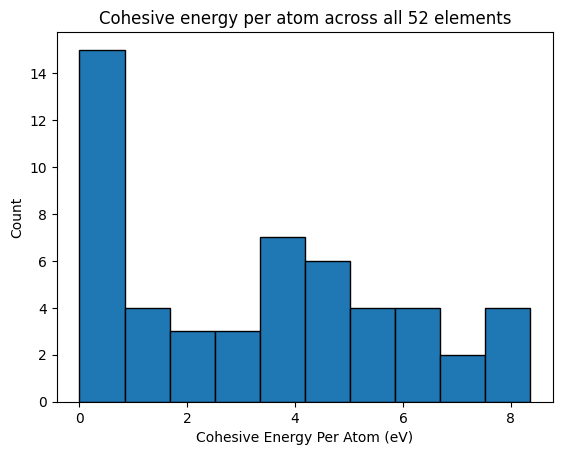

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.hist(elements['Cohesive Energy Per Atom (eV)'], bins=10, edgecolor='black')
ax.set_xlabel('Cohesive Energy Per Atom (eV)')
ax.set_ylabel('Count')
ax.set_title('Cohesive energy per atom across all 52 elements')
plt.show()

# Rapid-fire recap: common mistakes

*For each snippet: what's wrong, before reading the fix?*

**Mutating a filtered slice without `.copy()`:**
```python
hcp = elements[elements['Natural Crystal Structure'] == 'hcp']
hcp['Atomic Mass'] = hcp['Atomic Mass'] / 2   # SettingWithCopyWarning
```
`hcp` is a *view*, not guaranteed its own table. Fix: `.copy()` before mutating, or `.loc` on the original.

**`df['col'] = value` vs. `.loc[mask, 'col'] = value`:**
```python
elements['Vacancy Formation Energy (eV)'] = 0   # wipes the ENTIRE column
```
Fix: `elements.loc[elements['Natural Crystal Structure'] == 'bcc', 'Vacancy Formation Energy (eV)'] = 0`

**Loop-variable shadowing:**
```python
data = elements['Natural Crystal Structure'].dropna()
for data in data:      # reuses "data" as loop variable
    print(data)
print(data)             # no longer the Series
```
Fix: pick a loop variable name that doesn't collide with something you still need.

**Plotting without labels:**
```python
plt.hist(elements['Cohesive Energy Per Atom (eV)'])
plt.show()
```
Runs fine, still loses points — no axis labels, no title.

**`.mean()` and `NaN`:**
`.mean()` skips `NaN` by default — "the average" quietly means "the average of rows that had a value." Check `.isna().sum()` first.

# Quiz 2 (in class)

Closed-notes, ~20-25 min, exactly the six-item checklist above. A single small table (`elements.csv` or `periodic_table.csv`, no merge). Expect: load+inspect, compound-condition filter, a short accumulating loop, one loop-over-categories-and-plot question worth the most points.